# Lab 4 : Scatter Plots, Line Plots & Heatmaps

**Bibliothèques utilisées :**
[Pandas](https://pandas.pydata.org/docs/) | [Matplotlib](https://matplotlib.org/) | [Seaborn](https://seaborn.pydata.org/api.html)

---

## Contexte

On travaille avec le jeu de données **MPG** (Auto MPG dataset), initialement publié par la bibliothèque StatLib de l'Université Carnegie Mellon et disponible directement dans Seaborn (`sns.load_dataset("mpg")`).

Le dataset contient des informations sur la consommation de carburant (Miles Per Gallon) et les caractéristiques techniques de véhicules produits entre 1970 et 1982.

**Objectif :** explorer les relations entre variables via 3 types de graphiques :

1. **Scatter plot** — relation MPG vs puissance, coloré par origine
2. **Line plot** — évolution de la consommation moyenne par année
3. **Heatmap** — matrice de corrélation des variables continues

## Étapes

1. Importer les librairies
2. Charger et explorer le dataset
3. Produire les 3 visualisations

In [1]:
# =====================================================
# Step 1 : Import des librairies
# =====================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

<hr style="border: 2px solid black;">

## Step 2 : Chargement et exploration des données

In [2]:
# =====================================================
# Step 2 : Chargement du dataset MPG
# =====================================================
mpg_df = sns.load_dataset("mpg")
print(f"Shape : {mpg_df.shape}")
print(f"Colonnes : {mpg_df.columns.tolist()}")
mpg_df.head()

Shape : (398, 9)
Colonnes : ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
# Types et valeurs manquantes
print("=== Types ===")
print(mpg_df.dtypes)
print(f"\nValeurs manquantes :\n{mpg_df.isnull().sum()}")
print(f"\nStatistiques descriptives :")
mpg_df.describe()

=== Types ===
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

Valeurs manquantes :
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Statistiques descriptives :


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


**Résumé du dataset :**
- **398 lignes**, 9 colonnes
- Variables continues : `mpg`, `displacement`, `horsepower`, `weight`, `acceleration`
- Variables discrètes : `cylinders`, `model_year`, `origin`, `name`
- `horsepower` contient 6 valeurs manquantes (NaN)

<hr style="border: 2px solid black;">

## Step 3 : Visualisations

### Graphique 1 — Scatter plot : MPG vs Horsepower

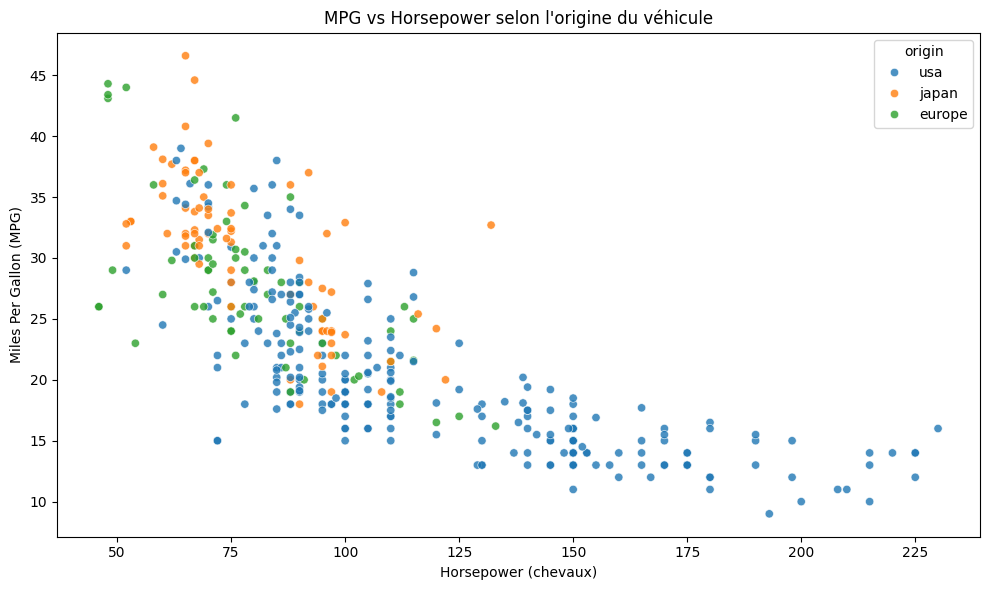

In [4]:
# =====================================================
# Graphique 1 : Scatter plot — MPG vs Horsepower
# =====================================================
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=mpg_df, x='horsepower', y='mpg', hue='origin',
                alpha=0.8, ax=ax)
ax.set_title('MPG vs Horsepower selon l\'origine du véhicule')
ax.set_xlabel('Horsepower (chevaux)')
ax.set_ylabel('Miles Per Gallon (MPG)')
plt.tight_layout()
plt.show()

**Observation :**
- Relation clairement **inversée** : plus la puissance augmente, plus la consommation (MPG) diminue.
- Les voitures japonaises (japan) se concentrent dans la zone basse puissance / haute efficacité.
- Les américaines (usa) dominent la zone haute puissance / basse efficacité — moteurs V6/V8 énergivores des années 70.
- Les européennes sont intermédiaires, plutôt proches des japonaises.

### Graphique 2 — Line plot : évolution du MPG moyen par année

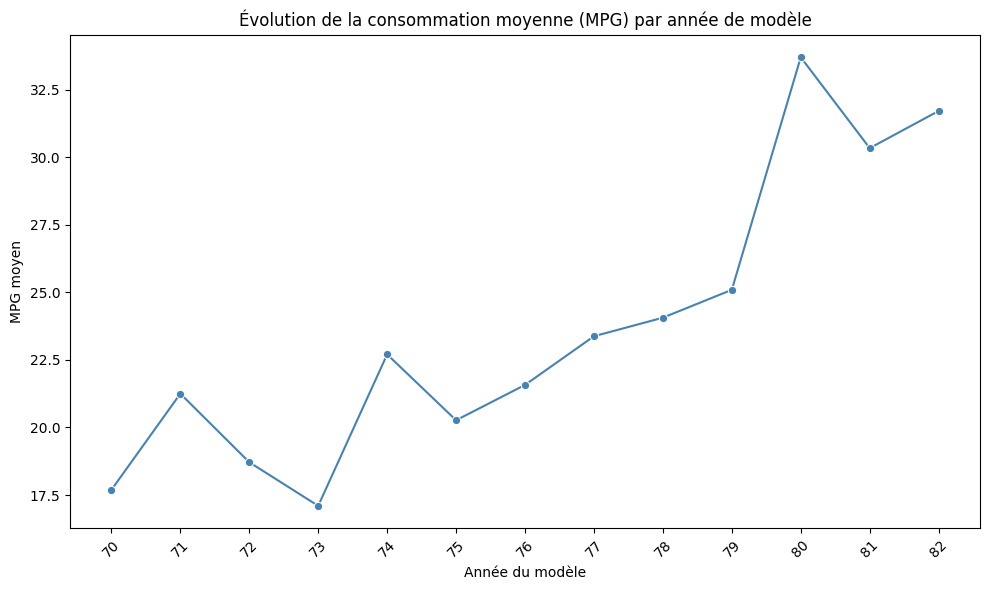

In [5]:
# =====================================================
# Graphique 2 : Line plot — MPG moyen par année de modèle
# =====================================================
avg_mpg_year = mpg_df.groupby('model_year')['mpg'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=avg_mpg_year, x='model_year', y='mpg',
             marker='o', color='steelblue', ax=ax)
ax.set_title('Évolution de la consommation moyenne (MPG) par année de modèle')
ax.set_xlabel('Année du modèle')
ax.set_ylabel('MPG moyen')
ax.set_xticks(avg_mpg_year['model_year'])
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Observation :**
- Tendance nettement **croissante** : le MPG moyen passe d'environ 17.5 en 1970 à ~34 en 1980.
- Creux visible en 1973 (~17 MPG) — les modèles de cette année étaient conçus avant le 1er choc pétrolier. À partir de 1974, la consommation s'améliore fortement.
- Accélération particulièrement forte entre 1978 et 1980 — période de réglementations environnementales renforcées aux USA (CAFE standards). Léger recul en 1981 probablement dû à un changement de mix de modèles.

### Graphique 3 — Heatmap : matrice de corrélation

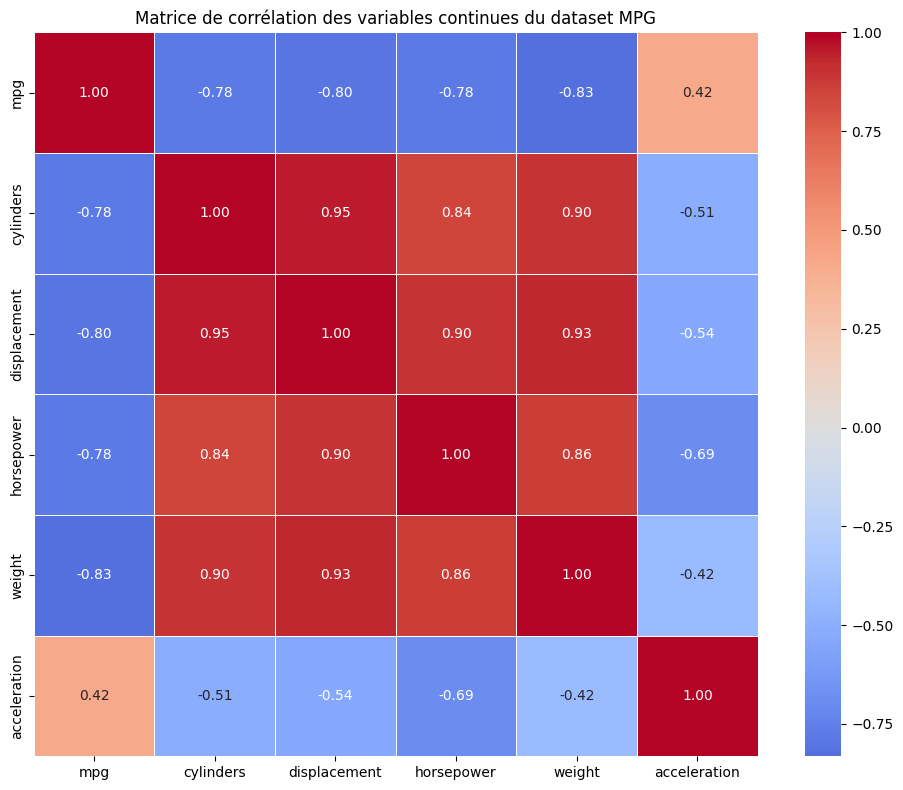

In [4]:
# =====================================================
# Graphique 3 : Heatmap — matrice de corrélation
# =====================================================
continuous_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
corr_matrix = mpg_df[continuous_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, ax=ax)
ax.set_title('Matrice de corrélation des variables continues du dataset MPG')
plt.tight_layout()
plt.show()

**Observation :**
- `displacement`, `horsepower`, `weight` et `cylinders` sont très fortement corrélés entre eux (>0.84) — ils mesurent tous la "taille" du moteur.
- `mpg` est fortement **anti-corrélé** avec ces 4 variables (r ≈ −0.80) — confirmation du scatter plot : gros moteur = faible efficacité.
- `acceleration` est la variable la moins corrélée avec les autres (r modéré ~0.40-0.50), car elle dépend du rapport poids/puissance plutôt que d'un seul facteur.